In [1]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

%matplotlib widget

In [2]:
project_name = "syn"
condition = "debug"
data = "biased_00"
switch_epoch = 0

checkpoint_epoch=0

n_samples = 500
show_results_fusion = False
fusion_attr_weight = 1.0
noise = 0.0

project_name = "syn"
experiment_name = get_experiment_name(condition, data, switch_epoch)


training_params = get_training_params(project_name, experiment_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_workspace = get_global_workspace(project_name, experiment_name, epoch=checkpoint_epoch)
data_module = get_data_module(project_name,  experiment_name)
samples = get_data_samples(data_module, n_samples, split ='train')

/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/debug_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/debug_biased_00/checkpoints/last.ckpt


In [3]:
unimodal_latents = global_workspace.encode_domains(samples)

# premier encodage: on reconstitue les attributs à partir du module vision
gw_latents = global_workspace.encode(unimodal_latents)

a2_from_v = split_softmax_category_attributes(
    global_workspace.decode(
        gw_latents[frozenset({'v_latents', 'attr'})]
        )['v_latents']['attr']
    )

# second encodage: on récupère les v_latents a partir des attributs
gw_latents_2 = global_workspace.encode({'attr': {'attr': torch.cat((a2_from_v[0], a2_from_v[1]), dim = 1)}})

v2_from_a2 = global_workspace.decode(
        gw_latents_2['attr']
        )['attr']['v_latents']

# troisième encodage: on reconstitue les attributs à partir du module vision
gw_latents_3 = global_workspace.encode({'v_latents': {'v_latents': v2_from_a2}})

a3_from_v2 = split_softmax_category_attributes(global_workspace.decode(
        gw_latents_3['v_latents']
        )['v_latents']['attr']
)

In [4]:
#torch.argmax(samples[frozenset({'v_latents', 'attr'})]['attr'][0], dim=1)
samples[frozenset({'v_latents', 'attr'})]['attr']

[tensor([[1, 0, 0],
         [0, 1, 0],
         [1, 0, 0],
         ...,
         [0, 0, 1],
         [0, 1, 0],
         [0, 0, 1]], device='cuda:0'),
 tensor([[-0.4444, -0.1111, -0.7143, -0.6711,  0.7413],
         [ 0.8889,  0.5556,  0.7143,  0.2991, -0.9542],
         [-0.7778, -0.6667, -0.7143,  0.6047, -0.7965],
         ...,
         [-0.1111, -0.7778,  0.1429, -0.0609, -0.9981],
         [ 0.2222,  0.8889,  0.4286, -0.9466,  0.3223],
         [-1.0000, -1.0000, -0.4286, -0.9821, -0.1884]], device='cuda:0')]

In [5]:
#torch.argmax(a3_from_v2[0], dim = 1)
global_workspace.decode(
        gw_latents[frozenset({'v_latents', 'attr'})]
        )['v_latents']['attr']

tensor([[ 5.6788,  1.1934, -1.7773,  ..., -0.9997, -0.9860,  0.2619],
        [ 1.0889, -2.2280, -0.7307,  ...,  0.9076,  0.3012,  0.1208],
        [ 0.8138,  1.2019,  0.0777,  ..., -0.9133,  0.8715, -0.7661],
        ...,
        [ 1.9156,  1.3204,  0.6654,  ..., -0.9521,  0.0146,  0.6449],
        [ 2.4358, -1.3915, -2.3865,  ..., -0.7167,  0.7215,  0.7221],
        [ 0.8393, -0.1003,  2.2792,  ..., -0.8091, -0.6095, -0.0247]],
       device='cuda:0', grad_fn=<CatBackward0>)

In [6]:
training_params

{'experiment_name': 'debug_biased_00',
 'exclude_colors': True,
 'apply_custom_init': True,
 'config': Config(seed=126, ood_seed=None, default_root_dir=PosixPath('checkpoints'), dataset=Dataset(path='/home/lucas/gwsyn/simple_shapes_dataset_biased_00'), training=Training(batch_size=2000, num_workers=16, devices=1, accelerator='gpu', fast_dev_run=False, max_steps=200000, enable_progress_bar=True, precision=32, float32_matmul_precision='highest', optim=Optim(lr=1e-05, max_lr=0.00015, start_lr=0.0001, end_lr=1e-05, pct_start=0.03, weight_decay=1e-06)), wandb=WanDB(enabled=True, save_dir='./wandb', project='Shimmer-SSD', entity='lexman-psl', reinit=False), logging=Logging(filter_images=['pred_trans_attr_to_attr', 'pred_trans_v_latents_to_v_latents', 'pred_trans_attr_to_v_latents', 'pred_trans_v_latents_to_attr', 'pred_cycle_v_latents_to_attr', 'pred_cycle_attr_to_v_latents', 'pred_cycle_v_latents_to_v_latents', 'pred_cycle_attr_to_attr'], log_train_medias_every_n_epochs=1, log_val_medias_ev

In [7]:
def get_n_per_category(source_tensor, current_attr, n_per_cat=10):
    """
    Retourne les n premiers éléments de source_tensor pour chaque catégorie 
    définie dans current_attr.
    
    Args:
        source_tensor: Le tenseur d'où on extrait les données (ex: des images ou latents)
        current_attr: Le tenseur de catégories (one-hot, ex: [Batch, 3])
        n_per_cat: Nombre d'éléments à extraire par catégorie
    """
    # 1. Convertir le one-hot en indices (0, 1, 2)
    labels = current_attr.argmax(dim=-1)
    
    # 2. Trouver les indices pour chaque classe
    indices_list = []
    num_classes = current_attr.shape[-1]
    
    for i in range(num_classes):
        # On récupère les indices où la classe est i
        indices = (labels == i).nonzero(as_tuple=True)[0]
        
        if len(indices) < n_per_cat:
            print(f"Warning: Seulement {len(indices)} éléments trouvés pour la classe {i}")
            indices_list.append(indices)
        else:
            # On ne garde que les n premiers
            indices_list.append(indices[:n_per_cat])
    
    # 3. Concaténer tous les indices sélectionnés
    all_indices = torch.cat(indices_list)
    
    # 4. Retourner le sous-ensemble du tenseur source
    return source_tensor[all_indices]

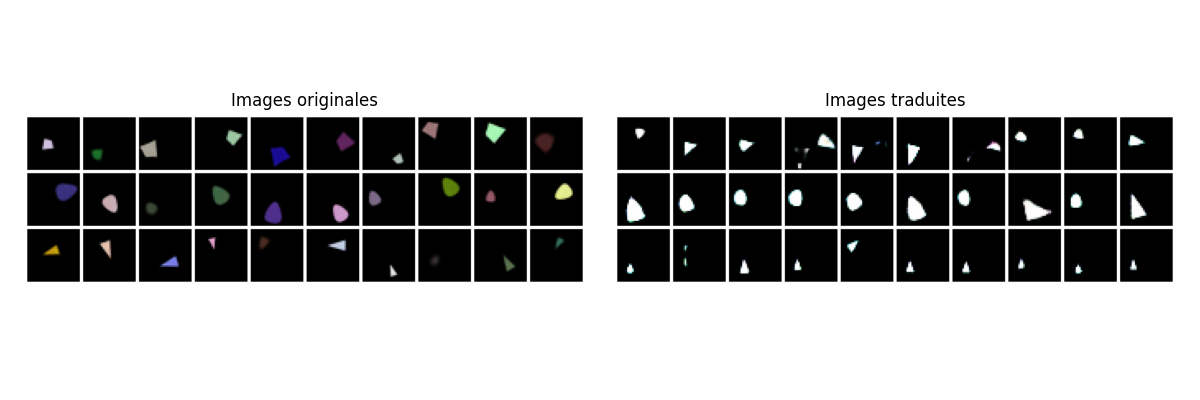

In [8]:
visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])

decoded_images_rgb = visual_module.decode_images(v2_from_a2)
original_images = samples[frozenset({'attr', 'v_latents'})]['v_latents']
original_images_rgb = visual_module.decode_images(original_images)

import matplotlib.pyplot as plt

current_attr = samples[frozenset({'attr', 'v_latents'})]['attr'][0]
fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, current_attr), get_n_per_category(decoded_images_rgb, current_attr))
plt.show()


In [9]:
current_attr

tensor([[1, 0, 0],
        [0, 1, 0],
        [1, 0, 0],
        ...,
        [0, 0, 1],
        [0, 1, 0],
        [0, 0, 1]], device='cuda:0')